In [2]:
import pandas as pd

df = pd.read_csv("data/maindataset.csv")
print(df.shape)
print(df.columns.tolist())

(6103, 11)
['Patient ID', 'Name', 'Age', 'Body Temperature(F) ', 'Heart rate(bpm)', 'Systolic Blood Pressure(mm Hg)', 'Diastolic Blood Pressure(mm Hg)', 'BMI(kg/m 2)', 'Blood Glucose(HbA1c)', 'Blood Glucose(Fasting hour-mg/dl)', 'Status']


In [3]:
df = df[(df['Age'] <= 100)]
df = df[(df['Body Temperature(F) '] >= 95) & (df['Body Temperature(F) '] <= 105)]
df = df[df['Diastolic Blood Pressure(mm Hg)'] >= 50]
print(df.shape)   # should land around 6058

(6058, 11)


In [4]:
df = df.drop(columns=['Name'])   # keep Patient ID only if you want a reference, otherwise drop that too

In [5]:
print(df.shape) 

(6058, 10)


In [6]:
features = ['Age', 'Body Temperature(F) ', 'Heart rate(bpm)', 
            'Systolic Blood Pressure(mm Hg)', 'Diastolic Blood Pressure(mm Hg)',
            'BMI(kg/m 2)', 'Blood Glucose(HbA1c)', 'Blood Glucose(Fasting hour-mg/dl)']

target = 'Status'

X = df[features]
y = df[target]

print(y.unique())

<StringArray>
['high risk', 'mid risk', 'low risk']
Length: 3, dtype: str


In [7]:
y = y.map({'low risk': 0, 'mid risk': 1, 'high risk': 2})

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
print(classification_report(y_test, dt.predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       400
           1       0.98      0.96      0.97       409
           2       0.97      0.98      0.98       403

    accuracy                           0.98      1212
   macro avg       0.98      0.98      0.98      1212
weighted avg       0.98      0.98      0.98      1212



In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
print(classification_report(y_test, rf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       400
           1       0.99      0.99      0.99       409
           2       0.99      0.99      0.99       403

    accuracy                           0.99      1212
   macro avg       0.99      0.99      0.99      1212
weighted avg       0.99      0.99      0.99      1212



In [11]:
import joblib
joblib.dump(rf, 'random_forest_model.pk1')


['random_forest_model.pk1']

In [12]:
import joblib #download model
joblib.dump(dt, 'decision_tree_model.pkl')

['decision_tree_model.pkl']

In [13]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)
print(classification_report(y_test, xgb.predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       400
           1       0.98      0.99      0.99       409
           2       1.00      0.98      0.99       403

    accuracy                           0.99      1212
   macro avg       0.99      0.99      0.99      1212
weighted avg       0.99      0.99      0.99      1212



In [14]:

import joblib
joblib.dump(xgb, 'xgboost_model.pk1')

['xgboost_model.pk1']

In [15]:
import os
print(os.listdir('.'))

['data', 'decision_tree_model.pkl', 'modelrf.ipynb', 'models', 'notebook.ipynb', 'random_forest_model.pk1', 'requirements.txt', 'visualization.ipynb', 'xgboost_model.pk1']


In [16]:
import shap
import joblib

rf = joblib.load("models/random_forest_model.pk1")
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

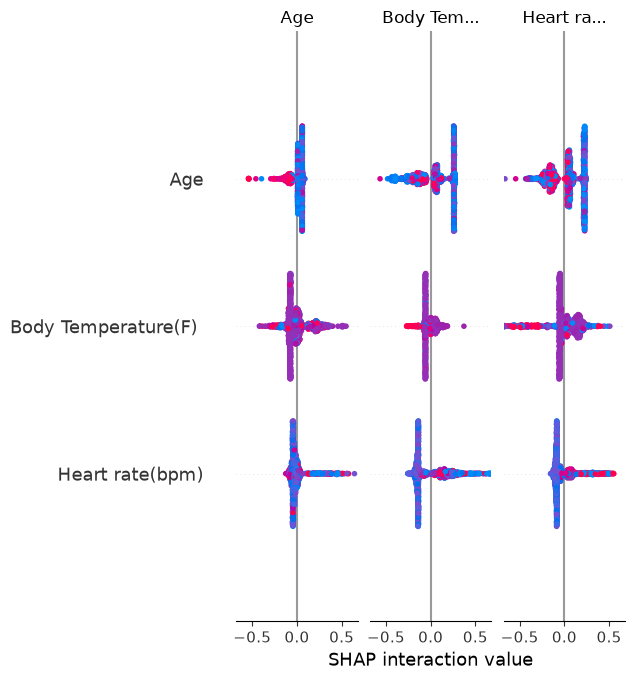

In [17]:
shap.summary_plot(shap_values, X_test)

In [18]:
print(shap_values.shape)

(1212, 8, 3)


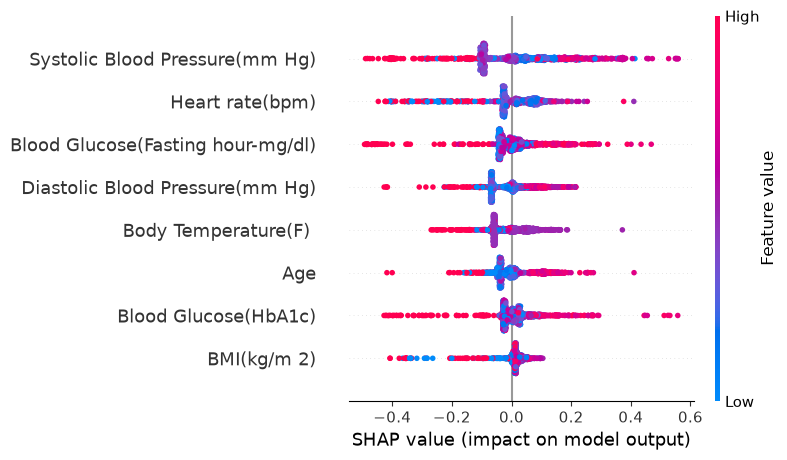

In [19]:
shap.summary_plot(shap_values[:, :, 1], X_test)

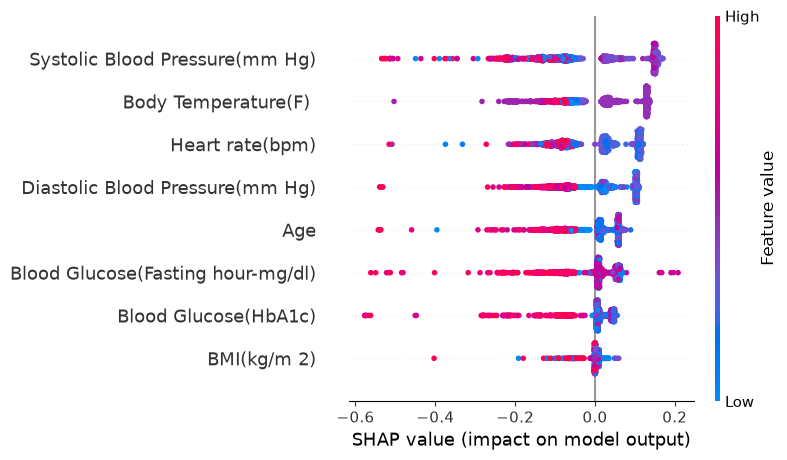

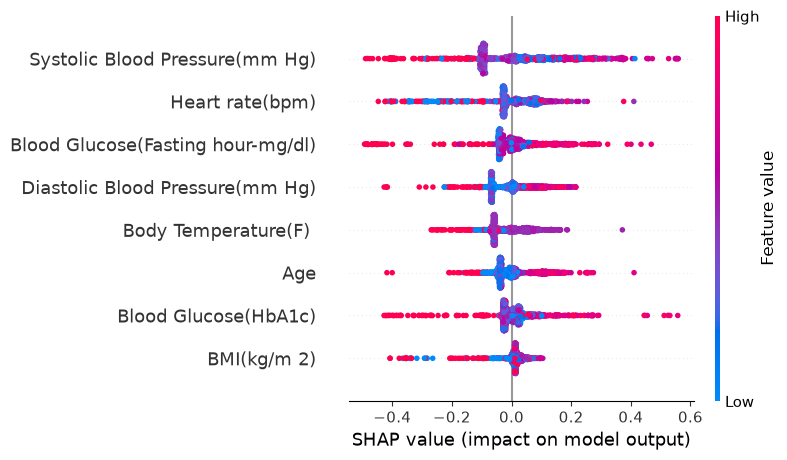

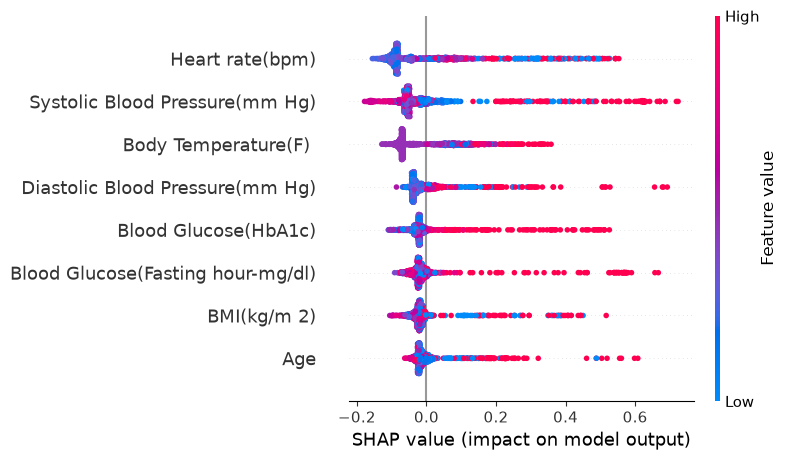

In [20]:
shap.summary_plot(shap_values[:, :, 0], X_test)  # low risk
shap.summary_plot(shap_values[:, :, 1], X_test)  # mid risk
shap.summary_plot(shap_values[:, :, 2], X_test)  # high risk

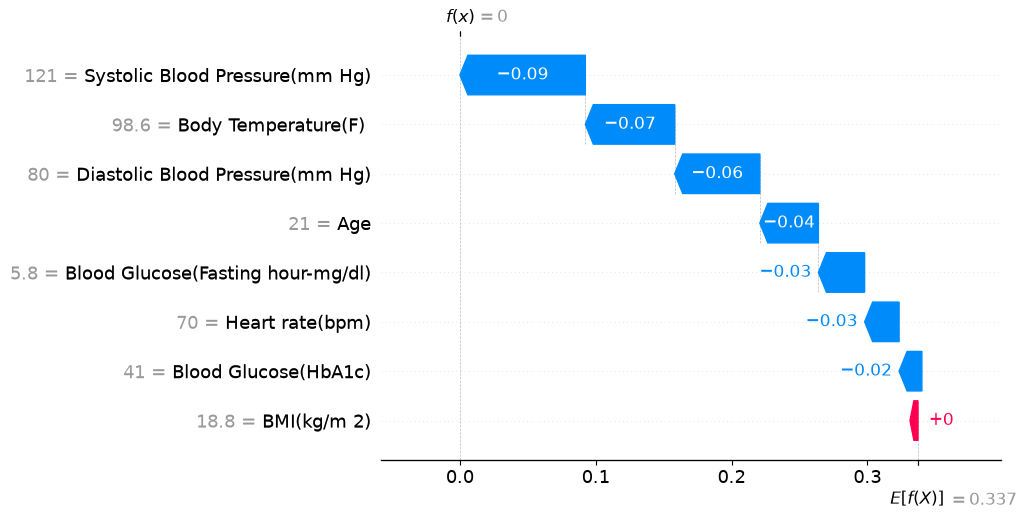

In [21]:
shap.plots.waterfall(shap.Explanation(
    values=shap_values[0, :, 1],  # first patient, all features, mid-risk class
    base_values=explainer.expected_value[1],
    data=X_test.iloc[0],
    feature_names=X_test.columns.tolist()
))

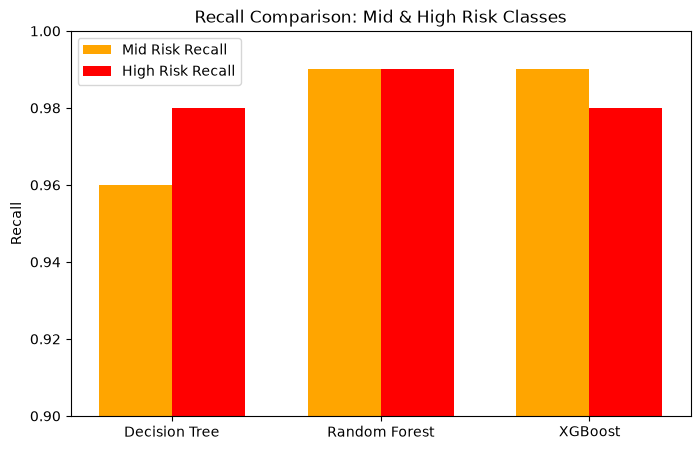

In [1]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Decision Tree', 'Random Forest', 'XGBoost']
mid_risk_recall = [0.96, 0.99, 0.99]
high_risk_recall = [0.98, 0.99, 0.98]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, mid_risk_recall, width, label='Mid Risk Recall', color='orange')
ax.bar(x + width/2, high_risk_recall, width, label='High Risk Recall', color='red')

ax.set_ylabel('Recall')
ax.set_title('Recall Comparison: Mid & High Risk Classes')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.9, 1.0)
ax.legend()
plt.show()

In [2]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, rf.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Mid', 'High'],
            yticklabels=['Low', 'Mid', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

NameError: name 'y_test' is not defined